<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

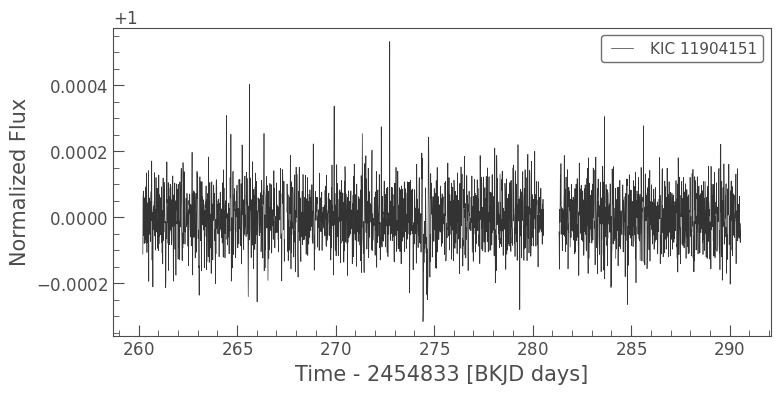

In [25]:
##pour etre sur que les graphiques s'affichent
%matplotlib inline 
import lightkurve as lk
import matplotlib.pyplot as plt

#on cherche les données de la nasa sur Kepler-10
search_result = lk.search_lightcurve("Kepler-10", quarter=3)

light_curve = search_result[0].download()
#On définie un temps de 0.01jour pour faire la moyenne des points avec le fonction .bin() afin de néttoyer le graphique
time_bin_size=0.01

#lisse la courbe pour corriger les erreurs humaines mais ne liss pas les transits
light_curve_flat = light_curve.flatten(window_length=401).bin(time_bin_size)
light_curve_flat.plot()



<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

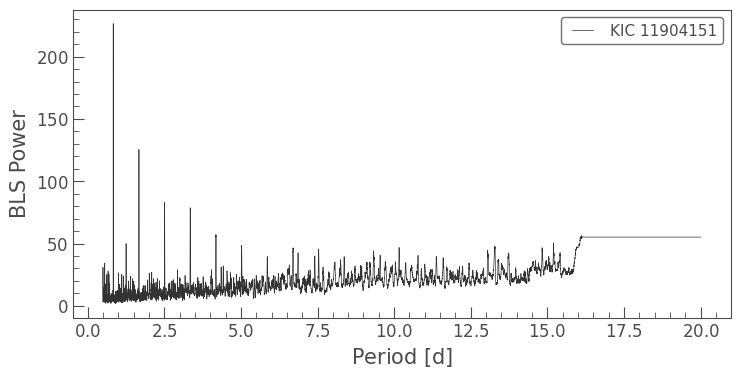

In [7]:
import numpy as np

# On va travailler sur 10000 instants entre 0.5 et 20 jours sur notre courbe
periods = np.linspace(0.5,20,10000)

#On utilise l'algorithme Bls pour détecter une planète
bls = light_curve_flat.to_periodogram(method='bls', period = periods)

bls.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

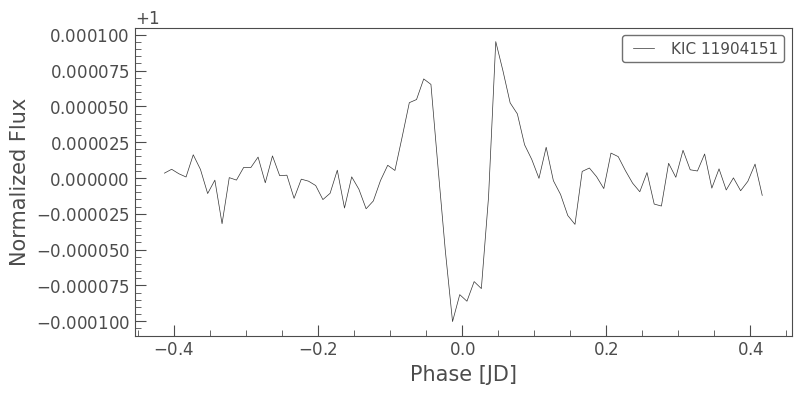

In [19]:

#on creer la phase avec la periode et le moment de début puis on affiche
phase = light_curve_flat.fold(period = 0.837, epoch_time= bls.transit_time_at_max_power ).bin(time_bin_size) 
phase.plot()

In [ ]:
def calculTaillePlanete():